# Distribuciones Continuas


## Distribuciones Continuas
Para modelar variables aleatorias discretas se tienen las siguientes funciones:

> **Probability Density Function (PDF) — Función de Densidad de Probabilidad**
> Para variables continuas, **no tiene sentido hablar de $P(X = x)$** (esa probabilidad es siempre 0). En cambio, se trabaja con la **PDF** $f(x)$, que describe cuán "densa" es la probabilidad alrededor de un valor.
>La probabilidad de que $X$ caiga en un intervalo es el área bajo la curva:
>$$P(a \leq X \leq b) = \int_a^b f(x)\, dx$$
>Dos propiedades:
>1. $f(x) \geq 0$
>2. $\int_{-\infty}^{\infty} f(x)\, dx = 1$

>**CDF continua**
> $$F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t)\, dt$$

**Media y varianza** 
La media y la varianza en este caso se computa de forma integral.
$$\mu = E[X] = \int_{-\infty}^{\infty} x f(x)\, dx$$

$$\sigma^2 = V[X] = \int_{-\infty}^{\infty} (x - \mu)^2 f(x)\, dx$$

Una terminología clave en el estudio de las probabilidad es continuas es
$\boldsymbol{z_\alpha}$, $\boldsymbol{t_{\alpha,\nu}}$.

Muy seguido en el curso aparecerán expresiones como $z_{0.025}$ o $t_{0.05, 10}$. Estas son notaciones para **cuantiles** de distribuciones.

>**Definición:** $z_\alpha$ es el valor $z$ tal que $P(Z > z_\alpha) = \alpha$, o equivalentemente:
>
> $$P(Z \leq z_\alpha) = 1 - \alpha$$

En Python, el cuantil se obtiene con **`.ppf(1 - alpha)`** (Percent Point Function = inversa de la CDF):

```python
z_alpha = stats.norm.ppf(1 - alpha)
```

Esta notación aplica para cualquier distribución: Normal, t, Chi-cuadrado, F, etc.

In [43]:
# --- z_alpha para la Normal estándar ----
print("=== Valores críticos Normal Estándar ===")
for alpha in [0.10, 0.05, 0.025, 0.01]:
    z = stats.norm.ppf(1 - alpha)
    print(f"z_{{alpha={alpha}}} = {z:.4f}->P(Z > {z:.4f}) = {alpha}")
print('\n')

# --- Verificación: P(Z > z_0.025) = 0.025 ---
z_025 = stats.norm.ppf(0.975)   # z tal que P(Z <= z) = 0.975
print(f"z_0.025 = {z_025:.4f}")
print(f"P(Z > {z_025:.4f}) = {stats.norm.sf(z_025):.4f}")

print('\n')
# ─── Para la distribución t con 10 grados de libertad ───
print("=== Valores críticos t(nu=10) ===")
for alpha in [0.10, 0.05, 0.025]:
    t = stats.t.ppf(1 - alpha, df=10)
    print(f"  t_{{alpha={alpha}, nu=10}} = {t:.4f}")

=== Valores críticos Normal Estándar ===
z_{alpha=0.1} = 1.2816->P(Z > 1.2816) = 0.1
z_{alpha=0.05} = 1.6449->P(Z > 1.6449) = 0.05
z_{alpha=0.025} = 1.9600->P(Z > 1.9600) = 0.025
z_{alpha=0.01} = 2.3263->P(Z > 2.3263) = 0.01


z_0.025 = 1.9600
P(Z > 1.9600) = 0.0250


=== Valores críticos t(nu=10) ===
  t_{alpha=0.1, nu=10} = 1.3722
  t_{alpha=0.05, nu=10} = 1.8125
  t_{alpha=0.025, nu=10} = 2.2281


### Distribución Uniforme Continua — `stats.uniform`

Todos los valores en el intervalo $[a, b]$ tienen la misma probabilidad.

**Parámetros:** $a$ (mínimo), $b$ (máximo)

$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

- $E[X] = \frac{a+b}{2}$
- $V[X] = \frac{(b-a)^2}{12}$

> **Ejemplo:** Error de redondeo, posición de un defecto en una línea de producción.

> ⚠️ En `scipy`, se parametriza como `uniform(loc=a, scale=b-a)`.

P(3 <= X <= 5) = 0.3333
Media: 5.00
Varianza: 3.00


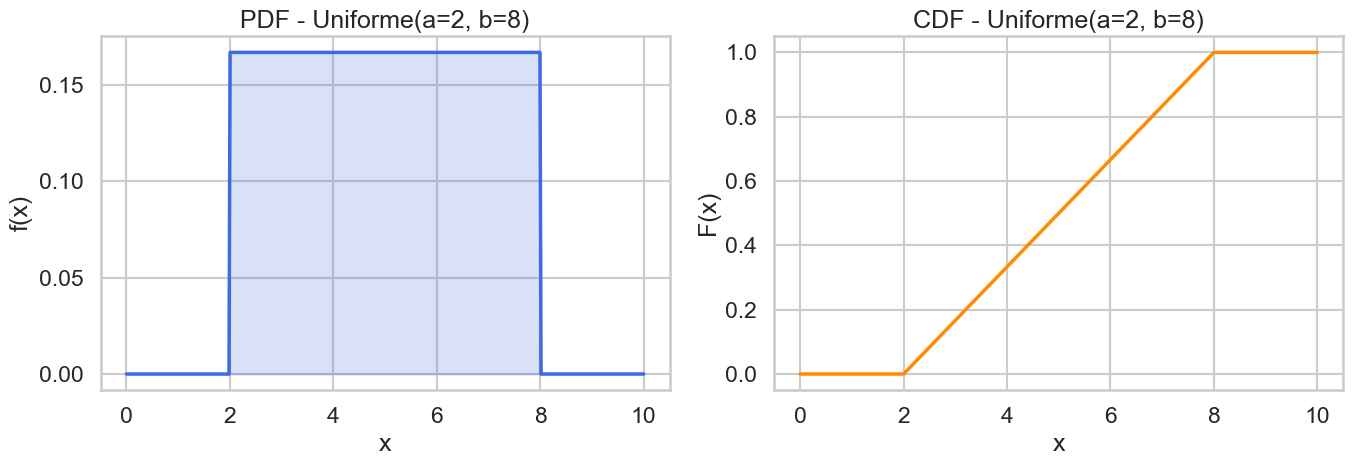

In [44]:
a, b = 2, 8

dist_unif = stats.uniform(loc=a, scale=b-a)

print(f"P(3 <= X <= 5) = {dist_unif.cdf(5) - dist_unif.cdf(3):.4f}")
print(f"Media: {dist_unif.mean():.2f}")
print(f"Varianza: {dist_unif.var():.2f}")

# ---- Gráfico -----
x = np.linspace(0, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, dist_unif.pdf(x), color='royalblue', linewidth=2.5)
axes[0].fill_between(x, dist_unif.pdf(x), alpha=0.2, color='royalblue')
axes[0].set_title(f'PDF - Uniforme(a={a}, b={b})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

axes[1].plot(x, dist_unif.cdf(x), color='darkorange', linewidth=2.5)
axes[1].set_title(f'CDF - Uniforme(a={a}, b={b})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')

plt.tight_layout()
plt.show()

### Distribución Normal — `stats.norm` ⭐

La más importante del curso (y de la estadística en general). Tiene la famosa forma de campana.

**Parámetros:** $\mu$ (media), $\sigma$ (desviación estándar)

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $E[X] = \mu$
- $V[X] = \sigma^2$

La **Normal Estándar** es cuando $\mu = 0$ y $\sigma = 1$, denotada $Z \sim N(0,1)$.

**Regla empírica (68-95-99.7):**
- $P(\mu - \sigma \leq X \leq \mu + \sigma) \approx 68\%$
- $P(\mu - 2\sigma \leq X \leq \mu + 2\sigma) \approx 95\%$
- $P(\mu - 3\sigma \leq X \leq \mu + 3\sigma) \approx 99.7\%$

> ⚠️ En `scipy`, `stats.norm(loc=μ, scale=σ)` — `scale` es la desviación estándar, **no** la varianza.

P(X < 12) = 0.8413
P(X > 14) = 0.0228
P(8 < X < 12) = 0.6827
Percentil 95 = 13.2897


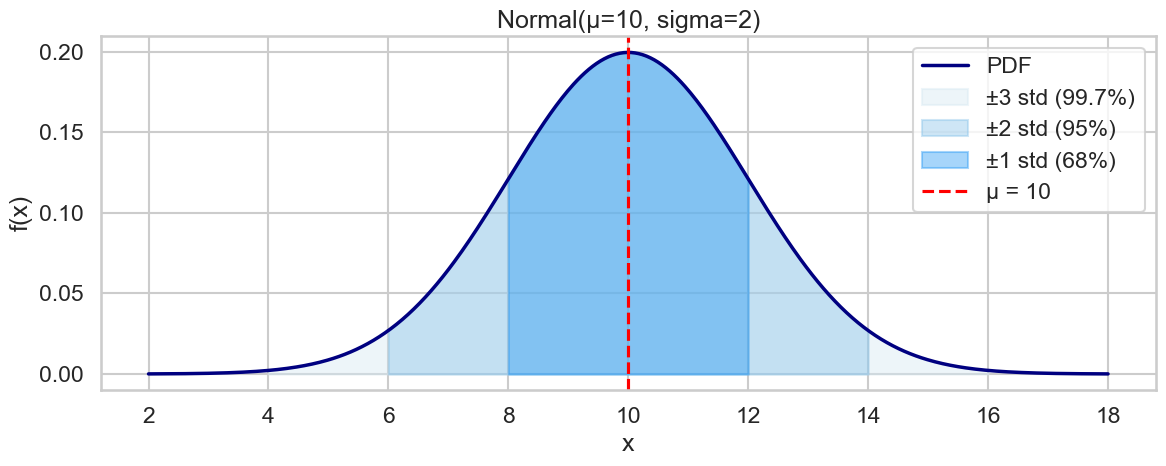

In [45]:
mu, sigma = 10, 2

dist_norm = stats.norm(loc=mu, scale=sigma)

# Probabilidades típicas
print(f"P(X < 12) = {dist_norm.cdf(12):.4f}")
print(f"P(X > 14) = {dist_norm.sf(14):.4f}")
print(f"P(8 < X < 12) = {dist_norm.cdf(12) - dist_norm.cdf(8):.4f}")

# Percentil 95: valor x tal que P(X <= x) = 0.95
x_95 = dist_norm.ppf(0.95)
print(f"Percentil 95 = {x_95:.4f}")

# ---- Gráfico PDF con áreas sombreadas ----
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, dist_norm.pdf(x), color='navy', linewidth=2.5, label='PDF')

# Sombrear región ±1σ, ±2σ, ±3σ
for nsigma, color, label in [(3, '#d4e6f1', '±3 std (99.7%)'),
                              (2, '#85c1e9', '±2 std (95%)'),
                              (1, '#2196F3', '±1 std (68%)')]:
    x_fill = np.linspace(mu - nsigma*sigma, mu + nsigma*sigma, 300)
    ax.fill_between(x_fill, dist_norm.pdf(x_fill), alpha=0.4, color=color, label=label)

ax.axvline(mu, color='red', linestyle='--', label=f'μ = {mu}')
ax.set_title(f'Normal(μ={mu}, sigma={sigma})')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend()
plt.tight_layout()
plt.show()

### Distribución Exponencial — `stats.expon`

Modela el **tiempo entre eventos** en un proceso de Poisson (tiempo hasta la próxima falla, tiempo entre llegadas).

**Parámetro:** $\lambda$ (tasa de eventos)

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

- $E[X] = \frac{1}{\lambda}$
- $V[X] = \frac{1}{\lambda^2}$

**Propiedad de sin memoria:** $P(X > s + t \mid X > s) = P(X > t)$ — el tiempo "no recuerda" cuánto ya ha pasado.

> ⚠️ `scipy` parametriza con `scale = 1/λ` (la media).

P(X > 3 horas) = 0.2231
P(X < 1 hora) = 0.3935
Media: 2.00 horas
Desv. estándar: 2.00 horas


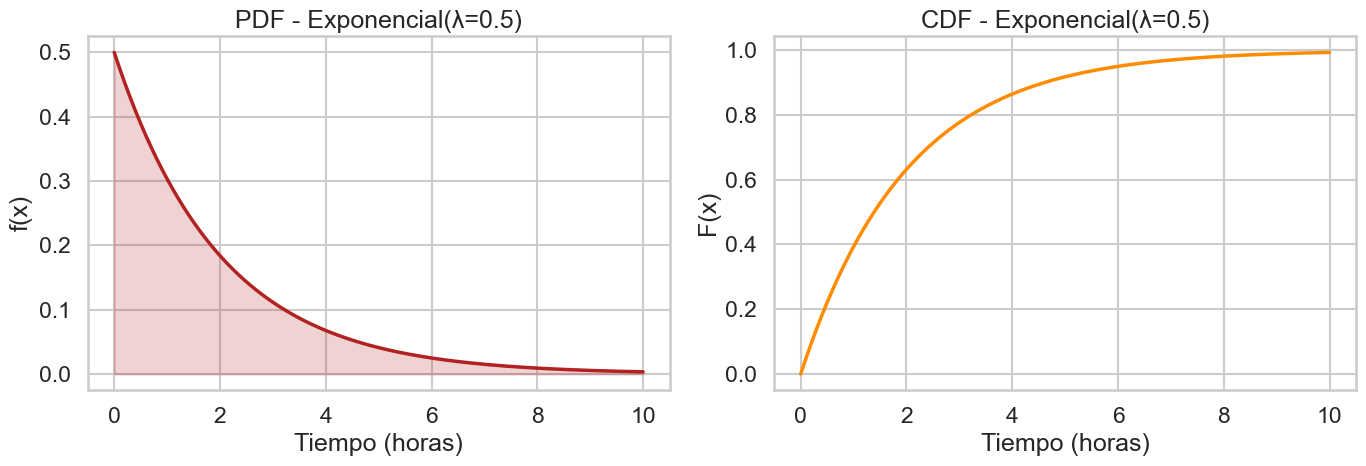

In [46]:
lam = 0.5  # 0.5 fallas por hora -> media = 2 horas entre fallas
scale = 1 / lam

dist_expon = stats.expon(scale=scale)

print(f"P(X > 3 horas) = {dist_expon.sf(3):.4f}")
print(f"P(X < 1 hora) = {dist_expon.cdf(1):.4f}")
print(f"Media: {dist_expon.mean():.2f} horas")
print(f"Desv. estándar: {dist_expon.std():.2f} horas")

# --- Gráfico ---
x = np.linspace(0, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, dist_expon.pdf(x), color='firebrick', linewidth=2.5)
axes[0].fill_between(x, dist_expon.pdf(x), alpha=0.2, color='firebrick')
axes[0].set_title(f'PDF - Exponencial(λ={lam})')
axes[0].set_xlabel('Tiempo (horas)'); axes[0].set_ylabel('f(x)')

axes[1].plot(x, dist_expon.cdf(x), color='darkorange', linewidth=2.5)
axes[1].set_title(f'CDF - Exponencial(λ={lam})')
axes[1].set_xlabel('Tiempo (horas)'); axes[1].set_ylabel('F(x)')

plt.tight_layout()
plt.show()

### Distribución t de Student — `stats.t`

Aparece cuando se estima la media de una población **normal con varianza desconocida** usando muestras pequeñas.  
Se parece a la Normal pero con **colas más pesadas** (más incertidumbre con pocos datos).

**Parámetro:** $\nu$ (grados de libertad, generalmente $\nu = n - 1$)

- $E[X] = 0$ (para $\nu > 1$)
- $V[X] = \frac{\nu}{\nu - 2}$ (para $\nu > 2$)

Cuando $\nu \to \infty$, la $t$ converge a la Normal estándar.

> **Uso principal en el curso:** pruebas de hipótesis e intervalos de confianza sobre medias.

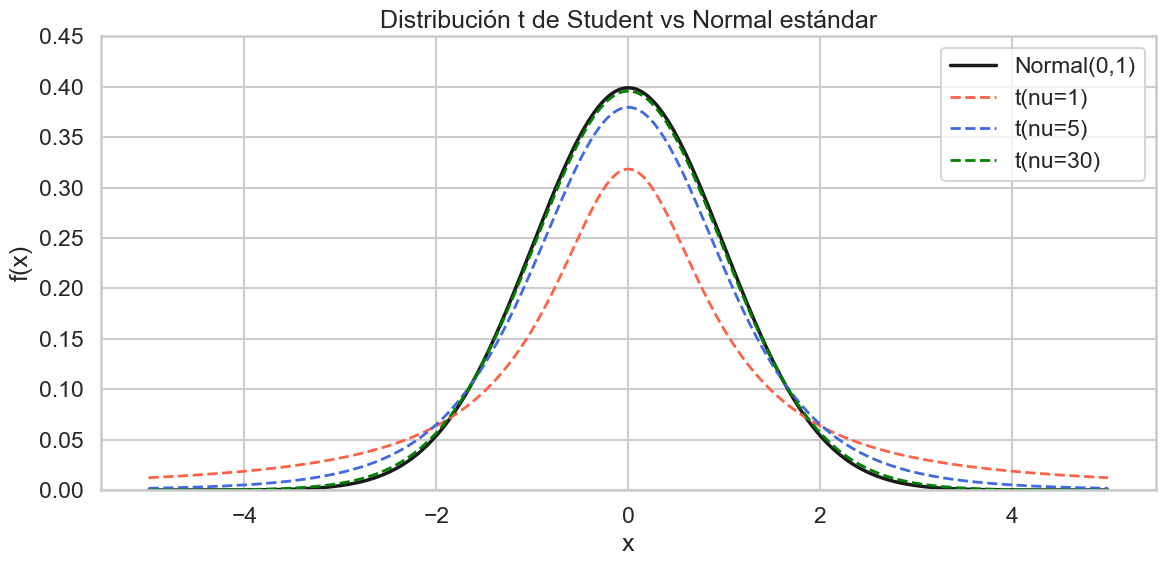

Valores críticos t_{sigma/2=0.025, nu}:
nu=  5: t_crit = 2.5706
nu= 10: t_crit = 2.2281
nu= 20: t_crit = 2.0860
nu= 30: t_crit = 2.0423
nu= 60: t_crit = 2.0003
nu=120: t_crit = 1.9799
nu=inf : z_crit = 1.9600  (Normal)


In [47]:
# Comparar t con distintos grados de libertad vs Normal
x = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, stats.norm.pdf(x), 'k-', linewidth=2.5, label='Normal(0,1)')
for df, color in [(1, 'tomato'), (5, 'royalblue'), (30, 'green')]:
    ax.plot(x, stats.t.pdf(x, df=df), '--', color=color, linewidth=2, label=f't(nu={df})')

ax.set_title('Distribución t de Student vs Normal estándar')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend()
ax.set_ylim(0, 0.45)
plt.tight_layout()
plt.show()

# Valores críticos t para distintos grados de libertad (α=0.05, dos colas)
print("Valores críticos t_{sigma/2=0.025, nu}:")
for df in [5, 10, 20, 30, 60, 120]:
    t_crit = stats.t.ppf(0.975, df=df)
    print(f"nu={df:3d}: t_crit = {t_crit:.4f}")
print(f"nu=inf : z_crit = {stats.norm.ppf(0.975):.4f}  (Normal)")

### Distribución Chi-cuadrado — `stats.chi2`

Si $Z_1, Z_2, \ldots, Z_\nu$ son normales estándar independientes, entonces:

$$\chi^2 = \sum_{i=1}^{\nu} Z_i^2$$

sigue una distribución Chi-cuadrado con $\nu$ grados de libertad.

**Parámetro:** $\nu$ (grados de libertad)

- $E[X] = \nu$
- $V[X] = 2\nu$

> **Uso principal en el curso:** pruebas de varianza, pruebas de bondad de ajuste ($\chi^2$), tablas de contingencia, y aparece en la distribución F.

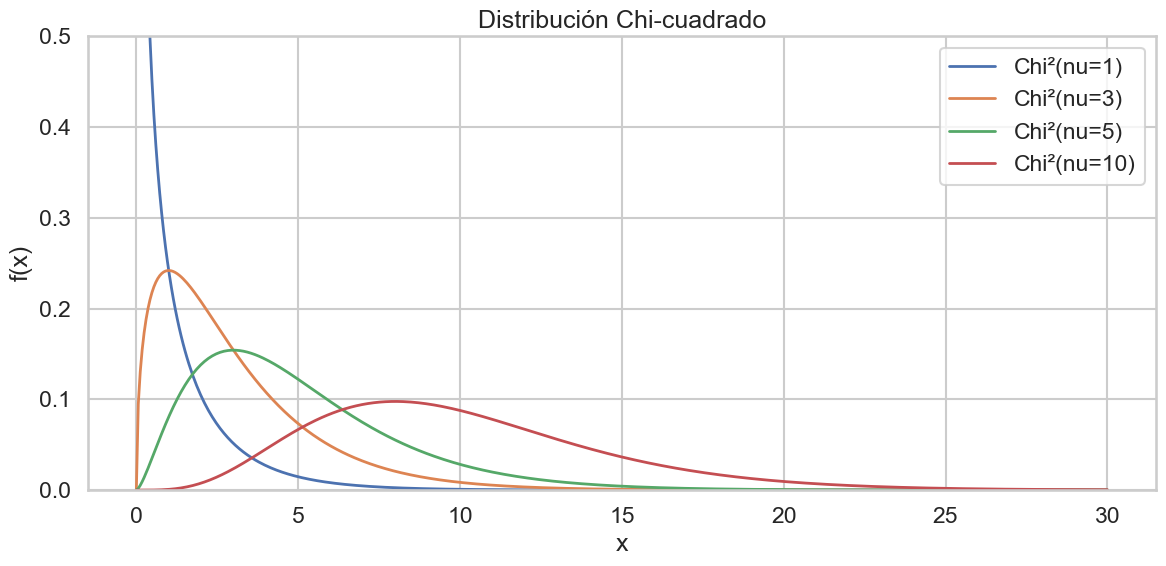

Chi²_{0.05, nu=10} = 18.3070   →   P(Chi² > 18.3070) = 0.05


In [48]:
x = np.linspace(0, 30, 500)

fig, ax = plt.subplots(figsize=(12, 6))
for df, color in [(1, 'tomato'), (3, 'royalblue'), (5, 'green'), (10, 'purple')]:
    ax.plot(x, stats.chi2.pdf(x, df=df), linewidth=2, label=f'Chi²(nu={df})')

ax.set_title('Distribución Chi-cuadrado')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_ylim(0, 0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Valor crítico chi2 (α=0.05, ν=10)
nu = 10
chi2_crit = stats.chi2.ppf(0.95, df=nu)
print(f"Chi²_{{0.05, nu={nu}}} = {chi2_crit:.4f}   →   P(Chi² > {chi2_crit:.4f}) = 0.05")

### Distribución F — `stats.f`

Es el cociente de dos Chi-cuadrado independientes (divididos por sus grados de libertad):

$$F = \frac{\chi^2_{\nu_1}/\nu_1}{\chi^2_{\nu_2}/\nu_2}$$

**Parámetros:** $\nu_1$ (grados de libertad del numerador), $\nu_2$ (grados del denominador)

- $E[X] = \frac{\nu_2}{\nu_2 - 2}$ (para $\nu_2 > 2$)
- Siempre positiva y asimétrica

> **Uso principal en el curso:** ANOVA, comparación de varianzas, regresión lineal (prueba F global). Probablemente sea la distribución que más usarán.

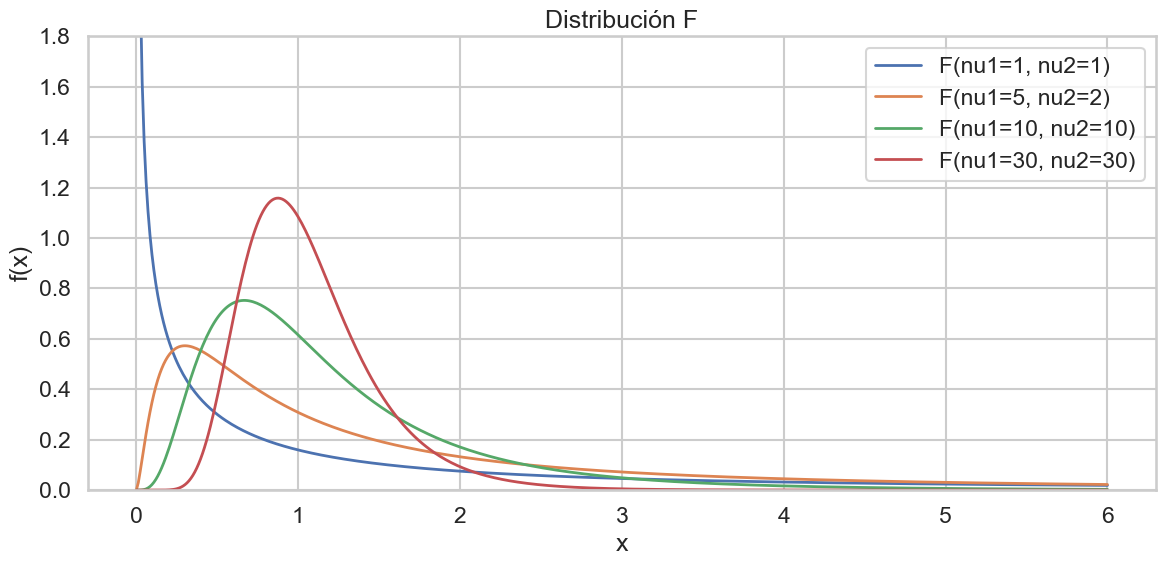

F_{0.05, nu1=3, nu2=20} = 3.0984 -> P(F > 3.0984) = 0.05


In [49]:
x = np.linspace(0, 6, 500)

fig, ax = plt.subplots(figsize=(12, 6))
for (d1, d2), color in [((1,1),'tomato'), ((5,2),'royalblue'),
                         ((10,10),'green'), ((30,30),'purple')]:
    ax.plot(x, stats.f.pdf(x, dfn=d1, dfd=d2), linewidth=2, label=f'F(nu1={d1}, nu2={d2})')

ax.set_title('Distribución F')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_ylim(0, 1.8)
ax.legend()
plt.tight_layout()
plt.show()

# Valor crítico F (α=0.05)
d1, d2 = 3, 20
f_crit = stats.f.ppf(0.95, dfn=d1, dfd=d2)
print(f"F_{{0.05, nu1={d1}, nu2={d2}}} = {f_crit:.4f} -> P(F > {f_crit:.4f}) = 0.05")

### Distribución Weibull — `stats.weibull_min`

Muy usada en ingeniería para modelar **tiempos de vida** y **confiabilidad** de equipos.

**Parámetros:** $\beta$ (forma / *shape*), $\delta$ (escala / *scale*)

$$f(x) = \frac{\beta}{\delta} \left(\frac{x}{\delta}\right)^{\beta-1} \exp\!\left[-\left(\frac{x}{\delta}\right)^\beta\right], \quad x \geq 0$$

- $\beta < 1$: tasa de falla decreciente (fallas tempranas)
- $\beta = 1$: tasa constante → equivale a Exponencial
- $\beta > 1$: tasa creciente (desgaste)

> ⚠️ En `scipy`, `weibull_min(c=β, scale=δ)`.

/opt/homebrew/Caskroom/miniconda/base/envs/SaaLab/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2747: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


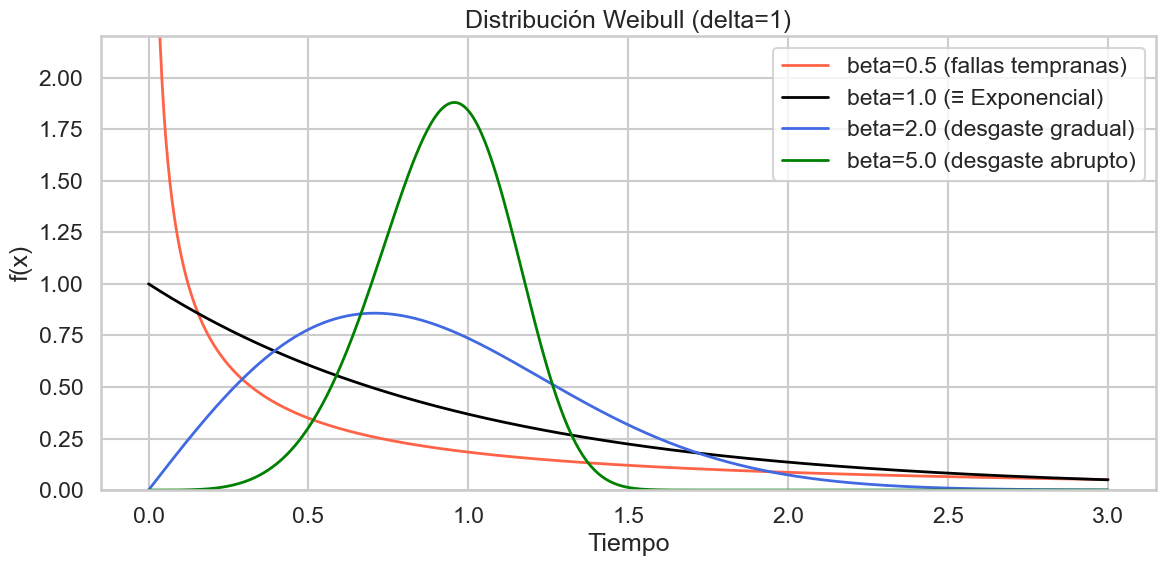

In [50]:
x = np.linspace(0, 3, 500)

fig, ax = plt.subplots(figsize=(12, 6))
for beta, color, label in [(0.5, 'tomato', 'beta=0.5 (fallas tempranas)'),
                            (1.0, 'black', 'beta=1.0 (≡ Exponencial)'),
                            (2.0, 'royalblue', 'beta=2.0 (desgaste gradual)'),
                            (5.0, 'green', 'beta=5.0 (desgaste abrupto)')]:
    ax.plot(x, stats.weibull_min.pdf(x, c=beta, scale=1), linewidth=2,
            color=color, label=label)

ax.set_title('Distribución Weibull (delta=1)')
ax.set_xlabel('Tiempo'); ax.set_ylabel('f(x)')
ax.set_ylim(0, 2.2)
ax.legend()
plt.tight_layout()
plt.show()

### Resumen: Distribuciones Continuas

| Distribución | Parámetros | Media | Uso típico en el curso |
|---|---|---|---|
| Uniforme | $a, b$ | $(a+b)/2$ | Incertidumbre sin información adicional |
| Normal | $\mu, \sigma$ | $\mu$ | **La más usada.** Modelado general, TLC |
| Exponencial | $\lambda$ | $1/\lambda$ | Tiempos entre eventos, procesos de Poisson |
| t de Student | $\nu$ | $0$ | Pruebas de hipótesis con varianza desconocida |
| Chi-cuadrado | $\nu$ | $\nu$ | Pruebas de varianza, bondad de ajuste |
| F | $\nu_1, \nu_2$ | $\approx 1$ | ANOVA, regresión, comparación de varianzas |
| Weibull | $\beta, \delta$ | — | Confiabilidad, tiempos de vida |

---
> 💡 **Truco útil:** En `scipy.stats`, todas las distribuciones tienen la misma interfaz (`.pdf`, `.cdf`, `.ppf`, `.rvs`). Si aprendes a usar una, sabes usar todas.